# Esercizio 3

Considero il modello a volatilità stocastica di Heston:

\begin{cases}
dS_t = \mu S_t dt + \sqrt{\nu_t} S_t dB_t^1,\\
d\nu_t = k(\theta - \nu_t) dt + \eta \sqrt{\nu_t} dB_t^2,
\end{cases}

dove $B^1, B^2$ sono moti Browniani correlati, definiti come

\begin{cases} 
B_t^1 =\sqrt{1-\rho^2}W_t^1 + \rho W_t^2, \\
B_t^2 = W_t^2,
\end{cases}

dove $W^1, W^2$ sono moti Browniani standard. La dinamica del sottostante è espressa sotto la misura martingala $\mathbb{Q}$, quindi $\mu$ rappresenta il tasso risk-free di mercato.

In [347]:
# Parametri del modello a volatilità stocastica di Heston:

S0 = 1.0        # prezzo iniziale del sottostante
mu = 0.03       # drift del sottostante, corrisponde al tasso risk-free
k = 5.0         # velocità di mean reversion della varianza
v0 = 0.04       # varianza iniziale
theta = 0.04    # varianza di lungo termine
eta = 0.3       # volatilità della varianza
rho = -0.7      # correlazione tra i due moti Browniani B^1, B^2
T = 0.5         # scadenza in anni

# array degli strike dell'opzione Call
KK = np.arange(start=0.5, stop=1.5 + 1e-10, step=0.1)

Tale scelta dei parametri soddisfa la condizione di Feller, infatti:

In [204]:
2*k*theta > eta**2

True

Quindi la soluzione della SDE della volatilità rimane positiva ed è ben definita:
$$
\nu_t > 0\quad \text{per ogni }t\geq 0, \quad\text{quasi certamente.}
$$
Scrivo la dinamica del logaritmo del prezzo del sottostante. Posto $X_t=log(S_t)$, per la formula di It$\hat{o}$ si ha:
\begin{align}
dX_t &= \frac{1}{S_t} dS_t - \frac{1}{2S_t^2}d\braket{S}_t\\
&= \mu dt + \sqrt{\nu_t}dB_t^1 - \frac{1}{2S_t^2} \nu_t S_t^2 d\braket{B^1}_t \\
&= \mu dt + \sqrt{\nu_t}\left(\sqrt{1-\rho^2} dW_t^1 + \rho dW_t^2\right) - \frac{1}{2} \nu_t d\braket{\sqrt{1-\rho^2} W^1+\rho W^2}_t \\
&= \mu dt + \sqrt{(1-\rho^2)\nu_t} dW_t^1 + \rho \sqrt{\nu_t} dW_t^2 - \frac{1}{2} \nu_t \left( (1-\rho^2)dt + \rho^2 dt\right) \\
&= \left(\mu - \frac{1}{2} \nu_t \right) dt + \sqrt{(1-\rho^2)\nu_t} dW_t^1 + \rho \sqrt{\nu_t} dW_t^2  \\ 
\end{align}
Simulando la dinamica del logaritmo del prezzo trasformiamo la SDE di partenza in una nuova SDE in cui i coefficienti non dipendono dal prezzo, quindi si riduce l'errore di approssimazione e il metodo risulta più stabile.
Scrivo la discretizzazione di Eulero del logaritmo del prezzo e della volatilità:
$$
\begin{cases}
X_{t+\Delta_t} = X_t + \left(\mu - \frac{1}{2} \nu_t \right) \Delta_t + \sqrt{(1-\rho^2)\nu_t} \Delta W_t^1 + \rho \sqrt{\nu_t} \Delta W_t^2, \quad\quad\quad\Delta W_t^1,\Delta W_t^2\sim\mathcal{N}(0,\Delta_t),\\
\nu_{t+\Delta_t} = \nu_t + k(\theta - \nu_t) \Delta_t + \eta \sqrt{\nu_t} \Delta W_t^2,
\end{cases}
$$
Nonostante la condizione di Feller sia soddisfatta, quando discretizziamo il processo è possibile che $\nu_t$ diventi negativo, creando problemi nella valutazione della radice quadrata. Per questo motivo aggiungiamo il seguente controllo sulla volatilità, detto Full Truncation Scheme, che è uno dei metodi che performa meglio secondo la letteratura:
$$
\begin{cases}
\nu_{pos} = \max{\{\nu_t, 0\}} \\
X_{t+\Delta_t} = X_t + \left(\mu - \frac{1}{2} \nu_{pos} \right) \Delta_t + \sqrt{(1-\rho^2)\nu_{pos}} \Delta W_t^1 + \rho \sqrt{\nu_{pos}} \Delta W_t^2, \\
\nu_{t+\Delta_t} = \nu_t + k(\theta - \nu_{pos}) \Delta_t + \eta \sqrt{\nu_{pos}} \Delta W_t^2,
\end{cases}
$$
Con questa soluzione impostiamo a zero il valore della varianza ogni volta che questa diventa negativa prima di procedere al calcolo del passo temporale successivo.

### Codice

In [208]:
import numpy as np
from scipy import stats
from scipy import linalg
from scipy import optimize
import matplotlib.pyplot as plt

In [552]:
# versione vettorizzata per il calcolo dell'opzione Call Europea
# K può essere un array

def heston_call(S0, mu, k, v0, theta, eta, rho, K, T, m, dt):
    tt = np.arange(start=0, stop=T + 1e-10, step=dt)
    n = len(tt)
    
    X0 = np.log(S0)
    X = np.zeros(shape=(n,m))
    X[0,:] = X0
    
    v = np.zeros(shape=(n,m))
    v[0,:] = v0
    
    for i in range(n-1):
        dW1 = stats.norm.rvs(size=m) * np.sqrt(dt)
        dW2 = stats.norm.rvs(size=m) * np.sqrt(dt)

        # implemento il Full Truncation Scheme per la varianza negativa
        v_pos = np.maximum(v[i,:], 0)
        X[i+1,:] = X[i,:] + (mu-0.5*v_pos)*dt + np.sqrt((1-rho**2)*v_pos)*dW1 + rho*np.sqrt(v_pos)*dW2
        v[i+1,:] = v[i,:] + k*(theta - v_pos)*dt + eta*np.sqrt(v_pos)*dW2
    
    S = np.exp(X)

    # adattiamo la forma di K
    K_array = np.asarray(K)
    if K_array.ndim > 0:
        # trasformiamo K in un vettore colonna
        K_array = K_array[:, np.newaxis]
        
    payoff = np.exp(-np.multiply(mu,T)) * (S[-1,:] - K_array).clip(min=0)
    
    # per il calcolo del valore atteso calcoliamo la media campionaria
    # dei payoff lungo l'ultimo asse (di dimensione m)
    # siccome np.shape(payoff) = (K_array.ndim, m)
    return {
        'price': payoff.mean(axis=-1),  
        'S': S,
        'X': X,
        'v': v,
    }

### Grafico delle traiettorie del sottostante nel modello di Heston

In [559]:
n_sim = 500
tt = np.arange(start=0, stop=T + 1e-10, step=dt)

results = heston_call(S0, mu, k, v0, theta, eta, rho, KK, T, n_sim, dt)
S_heston = results['S']
X_heston = results['X']
v_heston = results['v']

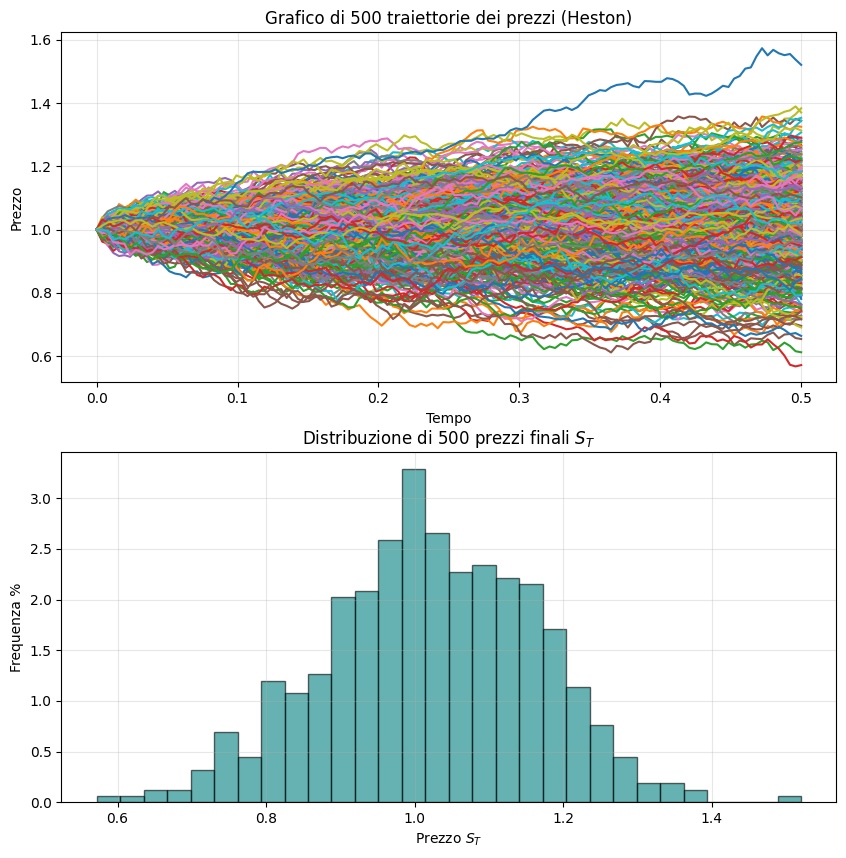

In [561]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))

# traiettorie del sottostante
ax[0].plot(tt, S_heston)
ax[0].set_title(f"Grafico di {n_sim} traiettorie dei prezzi (Heston)")
ax[0].set_xlabel('Tempo')
ax[0].set_ylabel('Prezzo')
ax[0].grid(True, alpha=0.3)

# istogramma della frequenza dei prezzi a scadenza T
ax[1].hist(S_heston[-1,:], bins=30, density=True, alpha=0.6, color='teal', edgecolor='black')
ax[1].set_title(f"Distribuzione di {n_sim} prezzi finali $S_T$")
ax[1].set_xlabel('Prezzo $S_T$')
ax[1].set_ylabel('Frequenza %')
ax[1].grid(True, alpha=0.3)

plt.show()

L'istogramma mostra una asimmetria negativa (skewness) della distribuzione delle frequenze empiriche dei prezzi finali, in quanto la coda sinistra è più spessa. L'asimmetria della distribuzione dei prezzi è dovuta dalla correlazione negativa tra i moti Browniani che descrivono la dinamica del sottostante e della varianza. Infatti quando il prezzo diminuisce, la volatilità tende ad aumentare, amplificando la probabilità di ottenere rendimenti negativi estremi.

### Grafico delle traiettorie della varianza nel modello di Heston

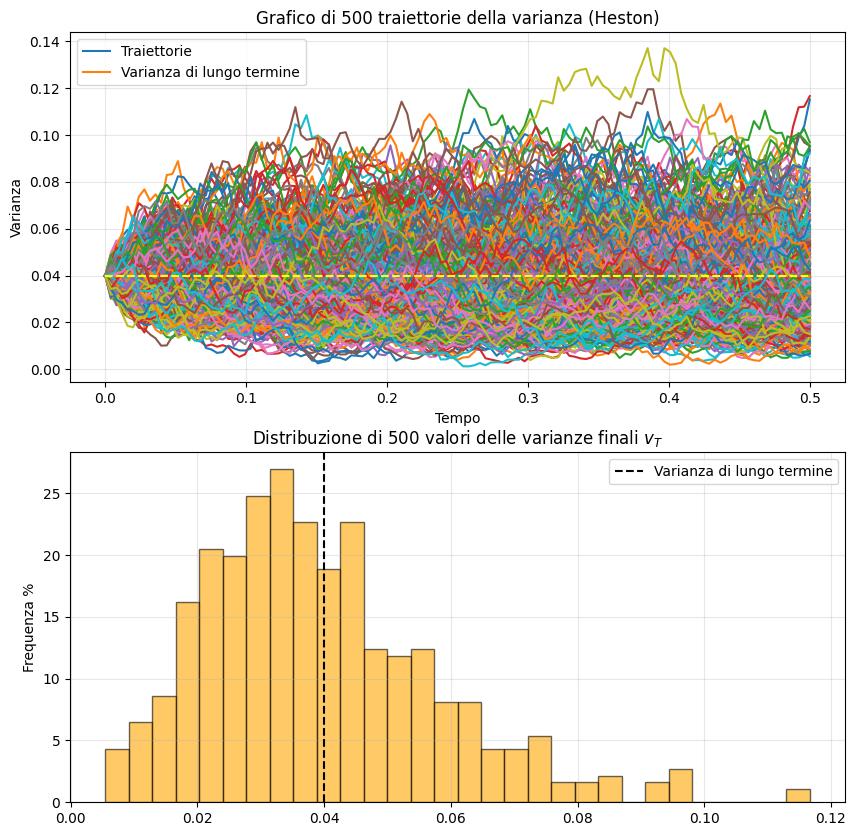

In [565]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))

# traiettorie della varianza
ax[0].plot(tt, v_heston)
ax[0].plot(tt, theta * np.ones_like(tt), label="Varianza di lungo termine", color='yellow', linestyle='--')
ax[0].set_title(f"Grafico di {n_sim} traiettorie della varianza (Heston)")
ax[0].set_xlabel('Tempo')
ax[0].set_ylabel('Varianza')
ax[0].legend(['Traiettorie', 'Varianza di lungo termine'], loc='best')
ax[0].grid(True, alpha=0.3)

# istogramma della frequenza dei valori della varianza a scadenza T
ax[1].hist(v_heston[-1,:], bins=30, density=True, alpha=0.6, color='orange', edgecolor='black')
ax[1].axvline(theta, color='black', linestyle='--', label='varianza di lungo termine')
ax[1].set_title('Distribuzione delle volatilità finali $v_T$')
ax[1].set_title(f"Distribuzione di {n_sim} valori delle varianze finali $v_T$")
ax[1].set_ylabel('Frequenza %')
ax[1].legend(['Varianza di lungo termine'], loc='best')
ax[1].grid(True, alpha=0.3)

plt.show()

### Distribuzione del logaritmo dei prezzi finali del sottostante

La distribuzione del logaritmo dei prezzi finali del sottostante non è una normale come nel modello di Black Scholes. E' una distribuzione leptocurtica.

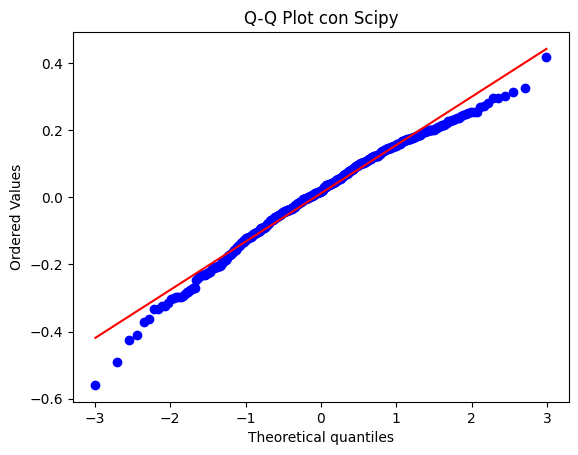

In [568]:
stats.probplot(X_heston[-1,:], dist="norm", plot=plt)

plt.title("Q-Q Plot con Scipy")
plt.show()

### Grafico dei prezzi dell'opzione Call Europea in funzione dello strike K

Calcolo il prezzo dell'opzione Call utilizzando il modello di Heston per tutti i valori di strike contenuti nell'array KK.

In [515]:
m = 1000000       # numero simulazioni Monte Carlo
dt = 1.0/252     # intervallo di tempo: Delta_t = 1 giorno

results = heston_call(S0, mu, k, v0, theta, eta, rho, KK, T, m, dt)
price_heston = results['price']

print(f"{'Strike K':<11} | {'Prezzo Call Heston':<10}")
print("="*35)

for i in range(len(KK)):
    print(f"{KK[i]:<10.2f} | {price_heston[i]:<15.6f}")

Strike K    | Prezzo Call Heston
0.50       | 0.507719       
0.60       | 0.409285       
0.70       | 0.311450       
0.80       | 0.216512       
0.90       | 0.130505       
1.00       | 0.063401       
1.10       | 0.022628       
1.20       | 0.005371       
1.30       | 0.000777       
1.40       | 0.000071       
1.50       | 0.000003       


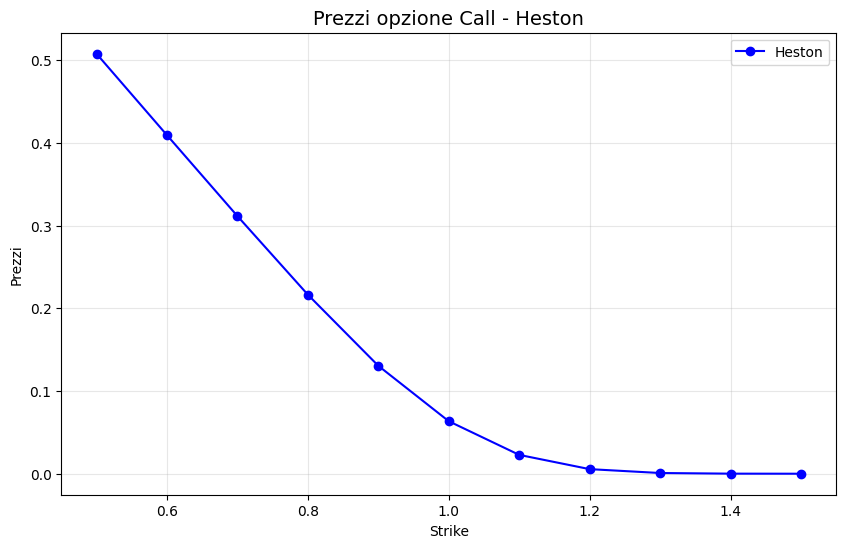

In [481]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(KK, price_heston, marker='o', linestyle='-', color='b', label='Heston')
ax.set_title('Prezzi opzione Call - Heston', fontsize=14)
ax.set_xlabel('Strike')
ax.set_ylabel('Prezzi')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

Come è noto a livello teorico, dal grafico si evidenzia come il prezzo dell'opzione Call è una funzione decrescente dello strike price.

L'andamento non segue una linea retta ma descrive una curva con una convessità che risultà più pronunciata nel punto $K=1.0$, dove lo strike coincide con il valore attuale del sottostante (l'opzione è at-the-money).

Successivamente, per strike superiori a $1.0$ l'opzione entra in territorio out-of-the-money e il prezzo diminuisce sensibilmente. Tuttavia, grazie alla volatilità stocastica e il coefficiente di correlazione ($\rho=-0.7$), il modello di Heston genera una distribuzione del sottostante caratterizzata da code spesse. Questo fatto comporta che anche opzioni con strike molto lontani possono mantenere un piccolo valore positivo, riflettendo correttamente il costo della copertura contro eventi di mercato rari ma violenti che il modello di Black Scholes non riuscirebbe a catturare.

# Volatilità implicita

Nel modello di Black Scholes possiamo calcolare il prezzo di una opzione Call Europea con la seguente formula chiusa:
$$
BS(S_0, K, T, r, \sigma)=S_0\Phi(d_+) - K e^{-rT}\Phi(d_-)
$$
con
$$
d_\pm=\frac{\log(\frac{S_0}{K})+rT}{\sigma\sqrt{T}}\pm\frac{1}{2}\sigma\sqrt{T}
$$
dove $\Phi$ è la funzione di ripartizione della distribuzione normale standard. Possiamo implementare la formula calcolando:
\begin{align}
s &\coloneqq\sigma\sqrt{T},\\
KrT &\coloneqq Ke^{-rT}, \\
d_+ &\coloneqq\frac{\log(\frac{S_0}{KrT})}{s}+\frac{s}{2},\\
d_- &\coloneqq d_+-s, \\
BS(S_0, K, T, r, \sigma) &=S_0\Phi(d_+) - KrT\Phi(d_-).
\end{align}

In [550]:
def bs_call(S0, K, T, r, vol):
    with np.errstate(divide='ignore', invalid='ignore'):
        s = vol*np.sqrt(T)
        KrT = np.exp(-np.multiply(r,T))*K
        d1 = np.log(S0/KrT)/s + s/2
        d2 = d1 - s
        C = S0*stats.norm.cdf(d1) - KrT*stats.norm.cdf(d2)
        C = np.where(np.isnan(C), 0.0, C)
    return C

## 1° metodo: funzione $\textit{fsolve}$ di SciPy

Calcolo la volatilità implicita con la funzione scipy.optimize.fsolve, ha il vantaggio di essere un metodo molto efficiente ma ha lo svantaggio di non essere vettorizzabile su array indipendenti.

In [409]:
def implied_volatility(price, S0, K, T, r):
    # Cerco la volatilità che annulla la differenza tra il prezzo BS e il prezzo Heston
    def obj_fun(x):
        return price - bs_call(S0, K, T, r, x)

    X0 = [0.1, 0.3, 0.5, 1.0, 3.0]  # Insieme dei valori della volatilità iniziale
    
    for x0 in X0:
        x, _, solved, _ = optimize.fsolve(obj_fun, x0, full_output=True, xtol=1e-8)
        if solved == 1:
            return x[0]
    return np.nan # Ritorna NaN se non trova una soluzione

In [529]:
IV_heston =[]

print(f"{'Strike K':<11} | {'Volatilità implicita Heston (fsolve)':<10}")
print("="*50)
for i in range(len(KK)):
    IV_heston.append(implied_volatility(price_heston[i], S0=S0, K=KK[i], T=T, r=mu))
    print(f" {KK[i]:<10.2f} | {IV_heston[i]:<15.6f}")
    
IV_heston = np.array(IV_heston)

Strike K    | Volatilità implicita Heston (fsolve)
 0.50       | 0.384750       
 0.60       | 0.300522       
 0.70       | 0.253353       
 0.80       | 0.230285       
 0.90       | 0.213317       
 1.00       | 0.198885       
 1.10       | 0.185825       
 1.20       | 0.174192       
 1.30       | 0.164121       
 1.40       | 0.156813       
 1.50       | 0.148795       


## 2° metodo: metodo di Newton

Calcolo la volatilità implicita con la funzione scipy.optimize.newton che implementa il metodo di Newton. Ha il vantaggio di essere vettorizzabile e richiede l'espressione della vega (derivata prima del prezzo dell'opzione Call rispetto a $\sigma$) che, per il modello di Black Scholes, è esprimibile in forma chiusa. Ha lo svantaggio che per grandi valori di $\sigma$ la vega può essere molto vicina a 0 e questo rallenta la convergenza del metodo.

Nel modello di Black Scholes la vega è data da
$$
\mathcal{V}=\frac{\partial BS}{\partial\sigma}(S_0, K, T, r, \sigma)=S_0\sqrt{T}\Phi'(d_+),
$$
dove $\Phi'(x)$ è la funzione di densità della distribuzione normale standard.

In [415]:
import warnings
from scipy.optimize import newton

def implied_volatility(price, S0, K, T, r):
    
    def obj_fun(vol, price, S0, K, T, r):
        return bs_call(S0, K, T, r, vol) - price
    
    def bs_vega(vol, price, S0, K, T, r):
        d1 = (np.log(S0/K) + (r + 0.5*vol**2)*T)/(vol*np.sqrt(T))
        vega = S0*stats.norm.pdf(d1)*np.sqrt(T)
        return np.where(vega < 1e-10, 1e-10, vega)
        
    vol_iniziale = [0.1, 0.3, 0.5, 1.0, 3.0]
    iv = np.full_like(K, np.nan, dtype=float)
    
    for v in vol_iniziale:
        # se tutti gli elementi hanno trovato convergenza, interrompiamo il ciclo
        if not np.isnan(iv).any():
            break
            
        initial_guess = np.full_like(K, v, dtype=float)
        
        # ignora i warning di Numpy e di SciPy se il metodo di Newton non dovesse convergere
        with warnings.catch_warnings(), np.errstate(all='ignore'):
            warnings.simplefilter("ignore", RuntimeWarning)
            res = newton(func=obj_fun, x0=initial_guess, fprime=bs_vega, args=(price, S0, K, T, r), tol=1e-8, maxiter=200, disp=False)
            
        errore = np.abs(bs_call(S0, K, T, r, res) - price)
          
        # definiamo valido il valore dove l'errore è minimo, la volatilità è positiva e dove non avevamo ancora trovato una soluzione
        valido = (errore < 1e-6) & (res > 0) & np.isnan(iv)
            
        # aggiorniamo iv solo dove il risultato è valido
        iv[valido] = res[valido]
            
    return iv

In [555]:
IV_heston = implied_volatility(price_heston, S0=S0, K=KK, T=T, r=mu)

print(f"{'Strike K':<11} | {'Volatilità implicita Heston (Newton)':<10}")
print("="*50)
for i in range(len(KK)):
    print(f" {KK[i]:<10.2f} | {IV_heston[i]:<15.6f}")

Strike K    | Volatilità implicita Heston (Newton)
 0.50       | 0.384750       
 0.60       | 0.300522       
 0.70       | 0.253353       
 0.80       | 0.230285       
 0.90       | 0.213317       
 1.00       | 0.198885       
 1.10       | 0.185825       
 1.20       | 0.174192       
 1.30       | 0.164121       
 1.40       | 0.156813       
 1.50       | 0.148795       


### Controllo: volatilità implicità del modello di Black Scholes

Calcolo la volatilità implicita del modello di Black Scholes e verifico che sia piatta, pertanto il modello non riproduce lo smile.
Calcolo il prezzo dell'opzione Call utilizzando il modello di Black Scholes utilizzando la volatilità di lungo periodo del modello di Heston:
$$
\sigma = \sqrt{\theta}.
$$

In [545]:
price_bs = bs_call(S0=S0, K=KK, T=T, r=mu, vol=np.sqrt(theta))

print(f"{'Strike K':<11} | {'Prezzo Call Black Scholes':<10}")
print("="*40)

for i in range(len(KK)):
    print(f" {KK[i]:<10.2f} | {price_bs[i]:<15.6f}")

Strike K    | Prezzo Call Black Scholes
 0.50       | 0.507444       
 0.60       | 0.408935       
 0.70       | 0.310578       
 0.80       | 0.214293       
 0.90       | 0.127993       
 1.00       | 0.063710       
 1.10       | 0.026119       
 1.20       | 0.008914       
 1.30       | 0.002589       
 1.40       | 0.000656       
 1.50       | 0.000149       


In [547]:
IV_bs = implied_volatility(price_bs, S0=S0, K=KK, T=T, r=mu) 

print(f"{'Strike K':<11} | {'Volatilità implicita Black Scholes':<10}")
print("="*50)
for i in range(len(KK)):
    print(f" {KK[i]:<10.2f} | {IV_bs[i]:<15.2f}")

Strike K    | Volatilità implicita Black Scholes
 0.50       | 0.20           
 0.60       | 0.20           
 0.70       | 0.20           
 0.80       | 0.20           
 0.90       | 0.20           
 1.00       | 0.20           
 1.10       | 0.20           
 1.20       | 0.20           
 1.30       | 0.20           
 1.40       | 0.20           
 1.50       | 0.20           


### Grafico dello smile di volatilità del modello di Heston

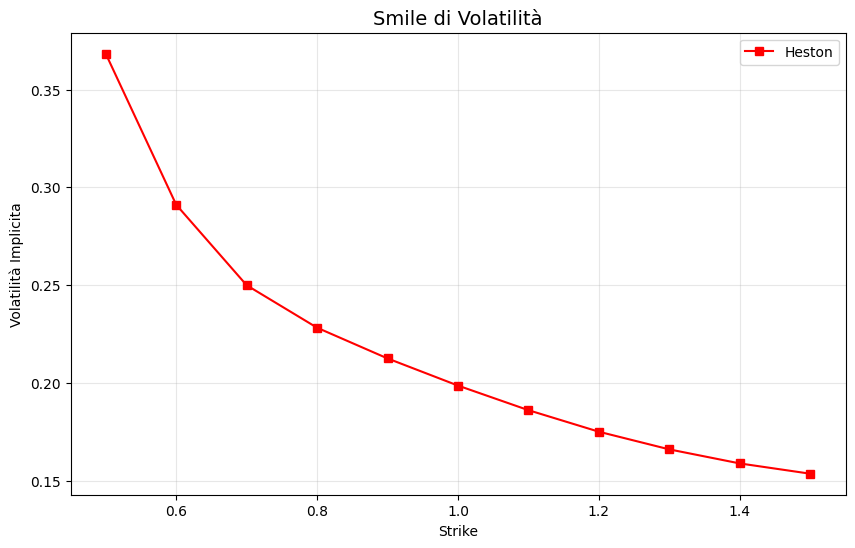

In [425]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(KK, IV_heston, marker='s', linestyle='-', color='r', label='Heston')
ax.set_title('Smile di Volatilità', fontsize=14)
ax.set_xlabel('Strike')
ax.set_ylabel('Volatilità Implicita')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

Il grafico della volatilità implicita conferma come il modello di Heston, a differenza del modello di Black Scholes, è in grado di riprodurre lo smile che si osserva empiricamente dai prezzi di mercato e cattura l'asimmetria dei rendimenti. In particolare la pendenza della curva è coerente con il parametro di correlazione $\rho=-0.7$: lo skew di volatilità assegna una volatilità più alta agli strike più bassi in quanto il modello assegna una probabilità maggiore agli eventi estremi negativi.
Lo smile dunque riflette la tendenza della volatilià ad aumentare durante le fasi di ribasso del mercato.

### Confronto: smile di volatilità di Heston vs Black Scholes

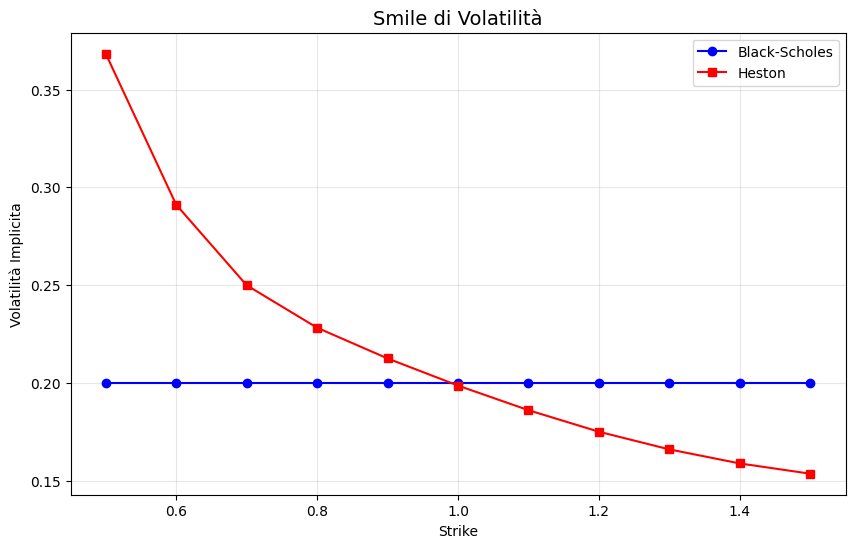

In [430]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(KK, IV_bs, marker='o', linestyle='-', color='b', label='Black-Scholes')
ax.plot(KK, IV_heston, marker='s', linestyle='-', color='r', label='Heston')
ax.set_title('Smile di Volatilità', fontsize=14)
ax.set_xlabel('Strike')
ax.set_ylabel('Volatilità Implicita')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()